In [1]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import torchaudio

In [2]:
# Load the data
data_2 = sio.loadmat('../data/phase2_data_20220215.mat')
samps_2 = pd.DataFrame(data_2['x'].T)
labs_2  = pd.DataFrame(data_2['y'].T, columns=['y'])

# Combine and drop any NaNs
df_2 = pd.concat([samps_2, labs_2], axis=1)

bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

df_2 = df_2.drop(index=bad_indices, errors='ignore')

df_2 = df_2.dropna()

shuffled_df = df_2.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

In [3]:
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=48000, #4800 samples 
    n_mfcc = 40,
    melkwargs = {
    "n_fft": 1024,      # ↑ more bins → no collapsed filters
    "hop_length": 512,  # ~10 ms hop
    "n_mels": 40,       # 40 mel bands for 40 MFCCs
    }
)
data_P2 = Extract_Features(df_X=df_X, df_Y=df_Y, feature="raw", transform=mfcc_transform)

In [4]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7400))
val_idx = list(range(7400,7600))
test_idx = list(range(7600,8228))

train_data = torch.utils.data.Subset(data_P2, train_idx)
val_data = torch.utils.data.Subset(data_P2, val_idx)
test_data = torch.utils.data.Subset(data_P2, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 50

print(train_loader.dataset[0][0].shape)

model = classify.MLP_3_layer(nb_hidden=64, input_dim=400, output_dim=2, dropout_rate=0.5)

history = loops.train(model=model, model_path="./model_paths/mfcc_p2.pth", train_loader=train_loader,val=True, val_loader=val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model_path="./model_paths/mfcc_p2.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

torch.Size([400])
[INFO] EPOCH: 1/50
Train loss: 0.574777, Train accuracy: 0.7322
Val loss: 0.714199, Val accuracy: 0.8100

[INFO] EPOCH: 2/50
Train loss: 0.470156, Train accuracy: 0.8378
Val loss: 0.572335, Val accuracy: 0.8550

[INFO] EPOCH: 3/50
Train loss: 0.427589, Train accuracy: 0.8573
Val loss: 0.515935, Val accuracy: 0.8950

[INFO] EPOCH: 4/50
Train loss: 0.399728, Train accuracy: 0.8850
Val loss: 0.549315, Val accuracy: 0.8900

[INFO] EPOCH: 5/50
Train loss: 0.380333, Train accuracy: 0.8968
Val loss: 0.512394, Val accuracy: 0.9000

[INFO] EPOCH: 6/50
Train loss: 0.363245, Train accuracy: 0.9116
Val loss: 0.556297, Val accuracy: 0.8950

[INFO] EPOCH: 7/50
Train loss: 0.352378, Train accuracy: 0.9162
Val loss: 0.584889, Val accuracy: 0.8700

[INFO] EPOCH: 8/50
Train loss: 0.347976, Train accuracy: 0.9214
Val loss: 0.599053, Val accuracy: 0.9100

[INFO] EPOCH: 9/50
Train loss: 0.332269, Train accuracy: 0.9338
Val loss: 0.495049, Val accuracy: 0.9100

[INFO] EPOCH: 10/50
Train lo

KeyboardInterrupt: 

torch.Size([400])
[INFO] EPOCH: 1/15
Train loss: 0.745462, Train accuracy: 0.6984
[INFO] EPOCH: 2/15
Train loss: 0.517448, Train accuracy: 0.7857
[INFO] EPOCH: 3/15
Train loss: 0.486445, Train accuracy: 0.8170
[INFO] EPOCH: 4/15
Train loss: 0.463583, Train accuracy: 0.8295
[INFO] EPOCH: 5/15
Train loss: 0.441133, Train accuracy: 0.8442
[INFO] EPOCH: 6/15
Train loss: 0.436464, Train accuracy: 0.8535
[INFO] EPOCH: 7/15
Train loss: 0.425939, Train accuracy: 0.8643
[INFO] EPOCH: 8/15
Train loss: 0.419210, Train accuracy: 0.8643
[INFO] EPOCH: 9/15
Train loss: 0.414049, Train accuracy: 0.8688
[INFO] EPOCH: 10/15
Train loss: 0.403412, Train accuracy: 0.8797
[INFO] EPOCH: 11/15
Train loss: 0.396953, Train accuracy: 0.8874
[INFO] EPOCH: 12/15
Train loss: 0.401049, Train accuracy: 0.8836
[INFO] EPOCH: 13/15
Train loss: 0.396252, Train accuracy: 0.8877
[INFO] EPOCH: 14/15
Train loss: 0.390445, Train accuracy: 0.8872
[INFO] EPOCH: 15/15
Train loss: 0.389047, Train accuracy: 0.8941
[INFO] Testing t

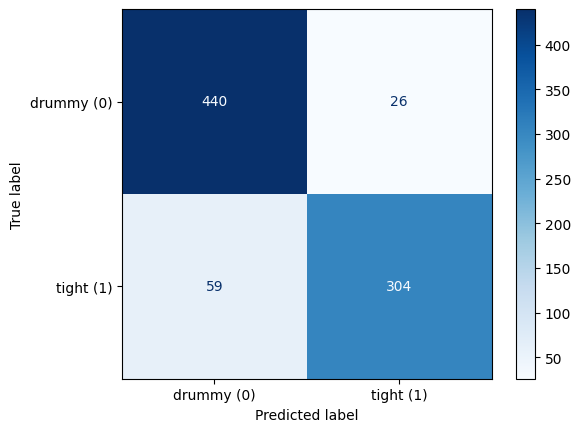


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.88      0.94      0.91       466
   tight (1)       0.92      0.84      0.88       363

    accuracy                           0.90       829
   macro avg       0.90      0.89      0.89       829
weighted avg       0.90      0.90      0.90       829



In [4]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(data_P2, train_idx)
test_data = torch.utils.data.Subset(data_P2, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 15

print(train_loader.dataset[0][0].shape)

model = classify.MLP(nb_hidden=64, input_dim=400, output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/mfcc_p2.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./model_paths/mfcc_p2.pth", test_loader=test_loader, report=True)


torch.Size([4800])
[INFO] EPOCH: 1/20
Train loss: 0.739754, Train accuracy: 0.6977
[INFO] EPOCH: 2/20
Train loss: 0.523747, Train accuracy: 0.7822
[INFO] EPOCH: 3/20
Train loss: 0.491405, Train accuracy: 0.8086
[INFO] EPOCH: 4/20
Train loss: 0.470831, Train accuracy: 0.8293
[INFO] EPOCH: 5/20
Train loss: 0.452240, Train accuracy: 0.8403
[INFO] EPOCH: 6/20
Train loss: 0.441934, Train accuracy: 0.8478
[INFO] EPOCH: 7/20
Train loss: 0.433173, Train accuracy: 0.8509
[INFO] EPOCH: 8/20
Train loss: 0.415415, Train accuracy: 0.8635
[INFO] EPOCH: 9/20
Train loss: 0.415735, Train accuracy: 0.8680
[INFO] EPOCH: 10/20
Train loss: 0.410418, Train accuracy: 0.8695
[INFO] EPOCH: 11/20
Train loss: 0.402760, Train accuracy: 0.8791
[INFO] EPOCH: 12/20
Train loss: 0.403018, Train accuracy: 0.8800
[INFO] EPOCH: 13/20
Train loss: 0.395717, Train accuracy: 0.8859
[INFO] EPOCH: 14/20
Train loss: 0.397459, Train accuracy: 0.8827
[INFO] EPOCH: 15/20
Train loss: 0.393386, Train accuracy: 0.8881
[INFO] EPOCH: 1

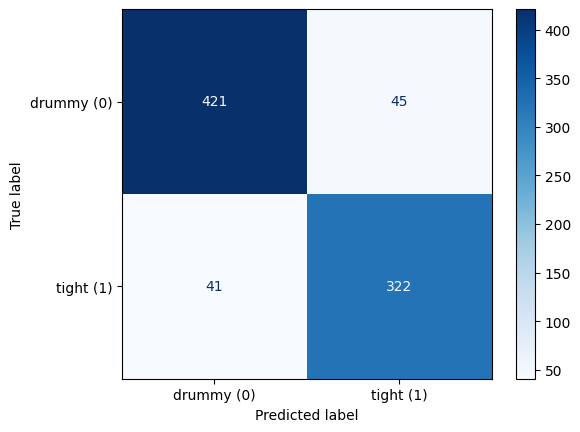


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.91      0.90      0.91       466
   tight (1)       0.88      0.89      0.88       363

    accuracy                           0.90       829
   macro avg       0.89      0.90      0.89       829
weighted avg       0.90      0.90      0.90       829



In [3]:
data_P2 = Extract_Features(df_X=df_X, df_Y=df_Y, feature="raw")
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(data_P2, train_idx)
test_data = torch.utils.data.Subset(data_P2, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 20

print(train_loader.dataset[0][0].shape)

model = models.MFCC()

loops.train(model=model, model_path="./model_paths/end_mfcc_p2.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./model_paths/end_mfcc_p2.pth", test_loader=test_loader, report=True)


In [5]:
onnx_model = models.MFCC()
onnx_model.load_state_dict(torch.load("./model_paths/end_mfcc_p2.pth"))
onnx_model.eval()

dummy_input = torch.randn((1,4800),dtype=torch.float32)
print(dummy_input.shape)

torch.onnx.export(
    onnx_model,                  # model to export
    (dummy_input,),        # inputs of the model,
    "./onnx/end_mfcc_p2.onnx",        # filename of the ONNX model
    input_names=["input"],  # Rename inputs for the ONNX model
    dynamo=False            # True or False to select the exporter to use
)

torch.Size([1, 4800])
Torch IR graph at exception: graph(%0 : Float(1, 4800, strides=[4800, 1], requires_grad=0, device=cpu),
      %mfcc_transform.dct_mat : Float(40, 40, strides=[1, 40], requires_grad=0, device=cpu),
      %mfcc_transform.MelSpectrogram.spectrogram.window : Float(1024, strides=[1], requires_grad=0, device=cpu),
      %mfcc_transform.MelSpectrogram.mel_scale.fb : Float(513, 40, strides=[40, 1], requires_grad=0, device=cpu),
      %classifier.0.weight : Float(64, 400, strides=[400, 1], requires_grad=1, device=cpu),
      %classifier.0.bias : Float(64, strides=[1], requires_grad=1, device=cpu),
      %classifier.3.weight : Float(2, 64, strides=[64, 1], requires_grad=1, device=cpu),
      %classifier.3.bias : Float(2, strides=[1], requires_grad=1, device=cpu)):
  %628 : Long(device=cpu) = prim::Constant[value={1}](), scope: models.models.MFCC::
  %482 : Float(1, 1, 4800, strides=[4800, 4800, 1], requires_grad=0, device=cpu) = aten::unsqueeze(%0, %628), scope: models.mode

/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages/torch/onnx/_internal/jit_utils.py:309: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:180.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)


SymbolicValueError: STFT does not currently support complex types  [Caused by the value '77 defined in (%77 : Float(*, *, strides=[5824, 1], requires_grad=0, device=cpu) = onnx::Reshape[allowzero=0](%66, %76), scope: models.models.MFCC::/torchaudio.transforms._transforms.MFCC::mfcc_transform/torchaudio.transforms._transforms.MelSpectrogram::MelSpectrogram/torchaudio.transforms._transforms.Spectrogram::spectrogram # /Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages/torch/functional.py:729:0
)' (type 'Tensor') in the TorchScript graph. The containing node has kind 'onnx::Reshape'.] 
    (node defined in /Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages/torch/functional.py(729): stft
/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages/torchaudio/functional/functional.py(126): spectrogram
/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/p

In [4]:
import os, shutil

dot = shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"

os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)
from torchview import draw_graph

model.eval()
graph = draw_graph(
    model,
    input_size=(1, 1, 4800),  # batch size first
    expand_nested=True,
    device='cpu',
    save_graph=True,
    filename='../assets/final_report_assets/mfcc_p2_model_arch',
)